In [ ]:
# --- MAIN PIPELINE CONTROLLER ---

# 1. IMPORTS
import step1_loading
import step2_preprocessing
import step3_epoching
import step4_pseudotrials
import step5_decoding
import step6_visualization
import step7_comparison
import matplotlib.pyplot as plt
import numpy as np


# 2. CONFIGURATION
SUBJECT_ID = 'sub-17'
BASIC_PATH = 'project/ds006761'

print(f"--- STARTING DUAL-PLAYER ANALYSIS: {SUBJECT_ID} ---")

# =================================================================
# STEP 1: LOAD FULL DATASET
# =================================================================
# Load the 143-channel file and split into two EEG objects using the new layout
raw_p1_full, raw_p2_full = step1_loading.load_and_split_data(SUBJECT_ID, BASIC_PATH)

# Store results for final comparison: { player_num: (times, scores) }
final_scores = {}

# =================================================================
# LOOP: PROCESS PLAYER 1 THEN PLAYER 2
# =================================================================
for player_num, raw_data in zip([1, 2], [raw_p1_full, raw_p2_full]):
    
    print(f"\n" + "="*50)
    print(f"   PROCESSING PLAYER {player_num}")
    print("="*50)

    if raw_data is None:
        print(f"❌ Missing data for Player {player_num}. Skipping.")
        continue

    # A. VISUALIZE RAW
    step1_loading.visualize_raw_data(raw_data, f"Player {player_num} (Raw)")

    # B. PREPROCESSING (Paper Replication)
    # No Filter, Interpolate, CAR, Resample
    raw_clean = step2_preprocessing.run_preprocessing(raw_data)
    step2_preprocessing.visualize_clean_data(raw_clean, f"Player {player_num} (Cleaned)")
    step2_preprocessing.visualize_ica_components(raw_clean, 15)

    # C. EPOCHING (Now returns a TUPLE)
    # We store the tuple in 'epochs_tuple'
    epochs_tuple, full_events_df = step3_epoching.run_epoching(raw_clean, SUBJECT_ID, BASIC_PATH, player_num)

    # ... inside the main loop ...

    # D. PSEUDO-TRIALS
    epochs_binned = step4_pseudotrials.create_pseudo_trials(epochs_tuple)

    # --- THE FIX IS HERE ---
    # 1. Extract Labels from the DataFrame
    # We need the 'playerX_resp' column that matches the valid trials
    current_labels = full_events_df[f'player{player_num}_resp'].values

    # 2. Pass these labels to Step 5
    times, scores = step5_decoding.run_svm_decoding(epochs_binned, custom_labels=current_labels)

    final_scores[player_num] = (times, scores)
    # -----------------------

    # F. VISUALIZATION
    step6_visualization.plot_paper_replication(times, scores, f"Player {player_num}")


    # G. COMPARATIVE ANALYSIS (Now Fixed)
    # We pass 'epochs_binned' (Array) and 'full_events_df' (Table)
    comp_results = step7_comparison.run_comparative_analysis(epochs_binned, full_events_df, player_num)
    
    # This will now plot the 4 lines with the correct 0-5s axis
    step7_comparison.plot_comparisons(comp_results, player_num)

# =================================================================
# FINAL STEP: HEAD-TO-HEAD VISUALIZATION
# =================================================================
print("\n" + "="*50)
print("   GENERATING FINAL COMPARISON: P1 vs P2")
print("="*50)

if 1 in final_scores and 2 in final_scores:
    t1, s1 = final_scores[1]
    t2, s2 = final_scores[2]
    
    plt.figure(figsize=(12, 6))
    
    # Plot Player 1
    plt.plot(t1, s1, label='Player 1 Accuracy', color='blue', linewidth=2)
    
    # Plot Player 2
    plt.plot(t2, s2, label='Player 2 Accuracy', color='orange', linewidth=2)
    
    # Reference Lines
    plt.axhline(33.33, color='k', linestyle='--', label='Chance (33%)') # 1/3 Chance
    plt.axvline(0, color='r', linestyle='-', alpha=0.5, label='Decision Onset')
    
    # Styling
    plt.title(f"Head-to-Head Decoding Performance: {SUBJECT_ID}")
    plt.xlabel("Time (s)")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()
    
    # Print Summary Stats
    p1_max = np.max(s1)
    p2_max = np.max(s2)
    print(f"Player 1 Max Accuracy: {p1_max:.2f}%")
    print(f"Player 2 Max Accuracy: {p2_max:.2f}%")
    
    if p1_max > p2_max:
        print("🏆 Player 1's brain was more readable (higher decoding accuracy).")
    else:
        print("🏆 Player 2's brain was more readable (higher decoding accuracy).")

else:
    print("Could not compare players (one or both missing).")

print("\n✅ Full Dual-Player Pipeline Complete.")

--- CONFIGURATION ---
Target Subjects: 34 subjects
Range: sub-01 to sub-34

--- STARTING PIPELINE ---

############################################################
   PROCESSING SUBJECT: sub-01
############################################################
--- [step1_loading] Reading project/ds006761/sub-01/eeg/sub-01_task-RPS_eeg.bdf ---
   -> Total Channels Detected: 143
   -> Layout detected: STANDARD (Gap between players).
   -> Splitting data into Player 1 and Player 2...
   -> Player 1 Channels: 64
   -> Player 2 Channels: 64
   -> Game Outcome: P1(159) vs P2(146) => Winner is Player 1

   --- Player 1 Analysis ---

--- [step2_preprocessing] Starting Cleaning Pipeline ---
   Original First Name: 1-A1
   -> Translating 64 BioSemi names to Standard 10-20 system...
   -> Success! New First Name: Fp1 (Should be Fp1)
   -> 10-20 System Montage applied.
   -> Applying CAR...
   -> Resampling to 256Hz...

--- [step3_epoching] Extracting 3 Phases (Dec, Resp, Feed) ---
Found 480 valid trial

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    3.9s remaining:    5.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


   -> ✅ Main Scores stored.
--- [step7_comparison] Analyzing Player 1 ---
--- [step5_decoding] Running SVM Decoding ---
   Data Shape: (480, 64, 20), Labels Shape: (480,)


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.5s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


--- [step5_decoding] Running SVM Decoding ---
   Data Shape: (478, 64, 20), Labels Shape: (478,)


...

--- [step5_decoding] Running SVM Decoding ---
   Data Shape: (473, 64, 20), Labels Shape: (473,)


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.7s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


--- [step5_decoding] Running SVM Decoding ---
   Data Shape: (472, 64, 20), Labels Shape: (472,)


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.7s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.7s finished


   -> ✅ Comparative Scores stored in 'Winner' group.

   GENERATING GRAND AVERAGE PLOTS (Winners vs Losers)

--- Winner Grand Averages ---
--- Plotting Grand Average Comparison for Player Winner ---


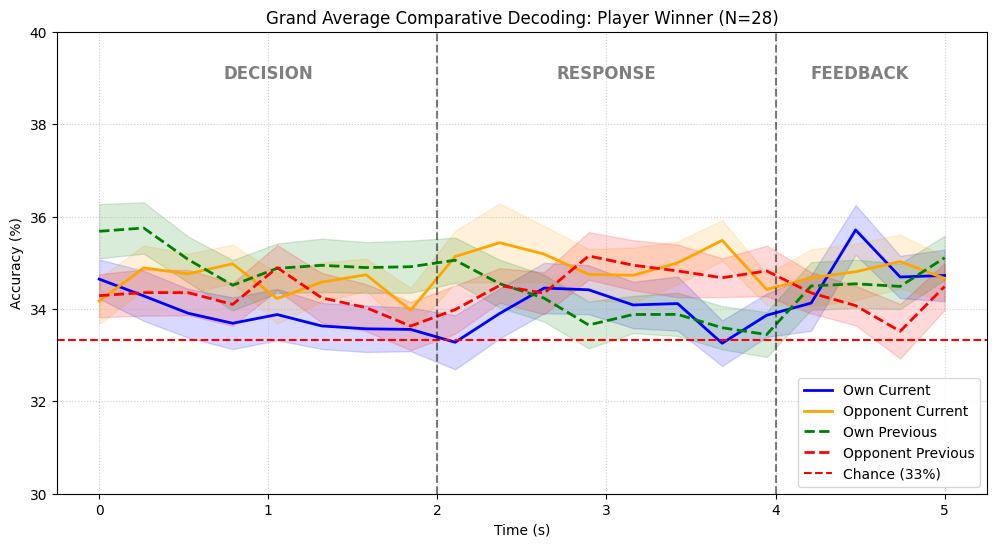


--- Loser Grand Averages ---
--- Plotting Grand Average Comparison for Player Loser ---


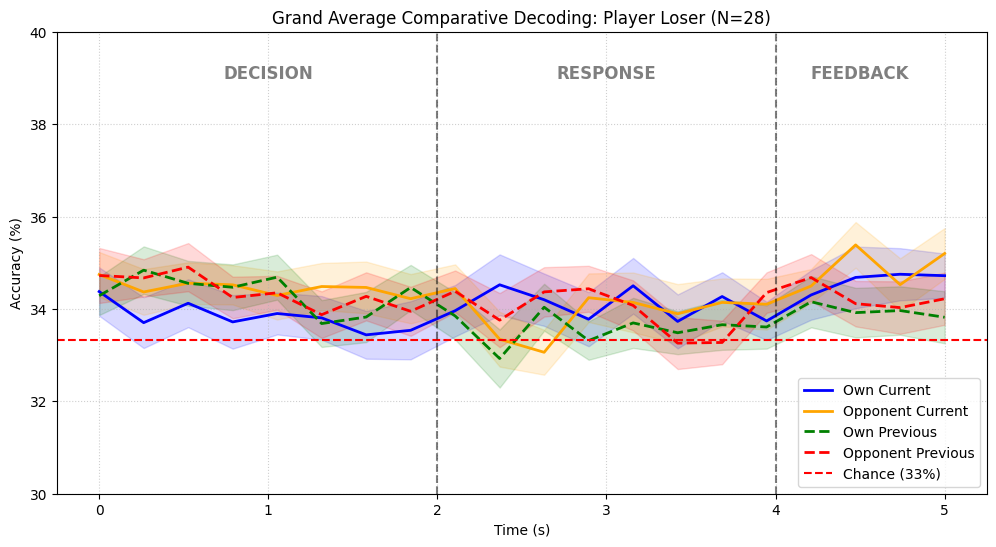


✅ Multi-Subject Analysis Complete.


In [1]:
# =================================================================
# 1. CONFIGURATION (MULTI-SUBJECT DYNAMIC)
# =================================================================
import step1_loading
import step2_preprocessing
import step3_epoching
import step4_pseudotrials
import step5_decoding
import step6_visualization
import step7_comparison
import numpy as np
import pandas as pd

# Dynamically generate Subject IDs from 01 to 34
START_SUB = 1
END_SUB = 34
SUBJECT_IDS = [f"sub-{i:02d}" for i in range(START_SUB, END_SUB + 1)]

BASIC_PATH = 'project/ds006761'

print(f"--- CONFIGURATION ---")
print(f"Target Subjects: {len(SUBJECT_IDS)} subjects")
print(f"Range: {SUBJECT_IDS[0]} to {SUBJECT_IDS[-1]}")

# Storage for Grand Average Analysis
# 1. Main Decoding
group_results = {1: [], 2: []} 

# 2. Comparative Decoding (Grouping by Game Outcome)
keys = ['Own Current', 'Opponent Current', 'Own Previous', 'Opponent Previous']
group_comp_results = {
    'Winner': {k: [] for k in keys},
    'Loser':  {k: [] for k in keys}
}

print(f"\n--- STARTING PIPELINE ---")

# =================================================================
# 2. OUTER LOOP: SUBJECTS
# =================================================================
for subject_id in SUBJECT_IDS:
    print(f"\n" + "#"*60)
    print(f"   PROCESSING SUBJECT: {subject_id}")
    print("#"*60)
    
    # Load Data for this Subject
    try:
        raw_p1_full, raw_p2_full = step1_loading.load_and_split_data(subject_id, BASIC_PATH)
    except Exception as e:
        print(f"❌ Failed to load {subject_id}: {e}")
        continue


    # --- DETERMINE GAME WINNER (Logic added) ---
    # We read the events file to count wins
    try:
        ev_file = f'{BASIC_PATH}/{subject_id}/eeg/{subject_id}_task-RPS_events.tsv'
        ev_df = pd.read_csv(ev_file, sep='\t')
        
        # Calculate scores (1=Rock, 2=Paper, 3=Scissors)
        # Logic: (P1 - P2) % 3 == 1 means P1 wins.
        p1_vals = ev_df['player1_resp'].values
        p2_vals = ev_df['player2_resp'].values
        
        # Count wins excluding NaNs
        valid_mask = np.isfinite(p1_vals) & np.isfinite(p2_vals)
        diff = (p1_vals[valid_mask] - p2_vals[valid_mask]) % 3
        
        p1_wins = np.sum(diff == 1)
        p2_wins = np.sum(diff == 2)
        
        subject_winner = 1 if p1_wins >= p2_wins else 2
        print(f"   -> Game Outcome: P1({p1_wins}) vs P2({p2_wins}) => Winner is Player {subject_winner}")
        
    except Exception as e:
        print(f"   ⚠️ Could not determine winner, defaulting to P1: {e}")
        subject_winner = 1
    # -------------------------------------------

    # =============================================================
    # 3. INNER LOOP: PLAYERS (1 & 2)
    # =============================================================
    for player_num, raw_data in zip([1, 2], [raw_p1_full, raw_p2_full]):
        
        if raw_data is None:
            print(f"   -> Skipping Player {player_num} (No Data)")
            continue
            
        print(f"\n   --- Player {player_num} Analysis ---")

        # A. PREPROCESSING + ICA
        raw_clean = step2_preprocessing.run_preprocessing(raw_data)

        # B. EPOCHING
        epochs_tuple, full_df = step3_epoching.run_epoching(raw_clean, subject_id, BASIC_PATH, player_num)

        # C. PSEUDO-TRIALS (Binning)
        epochs_binned = step4_pseudotrials.create_pseudo_trials(epochs_tuple)

        # D. MAIN DECODING (Own Current)
        current_labels = full_df[f'player{player_num}_resp'].values
        times, scores = step5_decoding.run_svm_decoding(epochs_binned, custom_labels=current_labels)
        
        if scores is not None:
            group_results[player_num].append(scores)
            print(f"   -> ✅ Main Scores stored.")
        else:
            print("   -> ❌ Main Decoding failed.")

        # Step G: Comparative Analysis
        comp_results = step7_comparison.run_comparative_analysis(epochs_binned, full_df, player_num)

        # Store these scores based on Winner/Loser status
        # Determine group key
        if player_num == subject_winner:
            group_key = 'Winner'
        else:
            group_key = 'Loser'

        for task_name, task_scores in comp_results.items():
            if task_scores is not None:
                # Append to 'Winner' or 'Loser' dict
                group_comp_results[group_key][task_name].append(task_scores)
        
        print(f"   -> ✅ Comparative Scores stored in '{group_key}' group.")

# =================================================================
# 4. FINAL STEP: GRAND AVERAGE VISUALIZATION
# =================================================================
# ... (Final Section) ...

print("\n" + "="*60)
print("   GENERATING GRAND AVERAGE PLOTS (Winners vs Losers)")
print("="*60)

grand_time_axis = np.linspace(0, 5.0, 20) 

# Iterate over the new groups
for group_name in ['Winner', 'Loser']:
    print(f"\n--- {group_name} Grand Averages ---")
    
    # Plot Comparative Decoding (4 Lines)
    step7_comparison.plot_grand_average_comparison(
        group_comp_results[group_name], 
        group_name  # Passes "Winner" or "Loser" as the title
    )

print("\n✅ Multi-Subject Analysis Complete.")